NOTEBOOK FOR RANDOM TESTING CODE 
======================



In [1]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing,make_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
# from sklearn.pipeline import make_pipeline

from tqdm import tqdm
from math import isclose

# globals

random_seed = 42       

----

# Testing df generation

### custom function from Prof Snyder

In [2]:
def f(x,degree):
    if degree==2:
        return 0.125*x**2 - 0.95*x + 1.925 
    elif degree==3:
        return 0.125*x**3 - 1.2*x**2 + 3*x + 0.5   
    elif degree==4:
        return 0.41*x**4 - 5.99*x**3 + 30.55*x**2 - 62.37*x + 41.4
    elif degree==5:
        return  -0.4*x**5 + 7.0*x**4 - 46.17*x**3 + 142.0*x**2 - 200.43*x + 102.0 
    elif degree==6:
        return -0.5219*x**6 + 10.7724*x**5 - 87.6206*x**4 + 355.7914*x**3 - 751.5246*x**2 + 774.0203*x - 300.917
    else:
        print("Degree must be in range [2..6]")
        return None
            


In [3]:
def make_poly_model(n_samples=10, degree=4,noise=1.0, show_data=False, show_model=True,random_state=random_seed):
    
    lb,ub = 1,6
            
    X_all = np.linspace(lb,ub,1000)
    y_perfect_model = f(X_all,degree)

    np.random.seed(random_state)
    X = np.linspace(lb,ub,n_samples)             # evenly spaced samples for simplicity
    y = f(X,degree) + np.random.normal(0, noise,size=n_samples)

    # Plotting the scatter plot of the data 

    if show_data:
      
        plt.figure(figsize=(8, 5))
        plt.scatter(X, y, marker='.',label=f'{n_samples} Data Points; Noise std = {noise}')
        if show_model:
            plt.plot(X_all, y_perfect_model, label='Underlying Model without noise', linestyle='--',color='grey', alpha=0.5)
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Degree {degree} Polynomial Noisy Dataset')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    return X.reshape(-1,1),y

### test


#f23a12

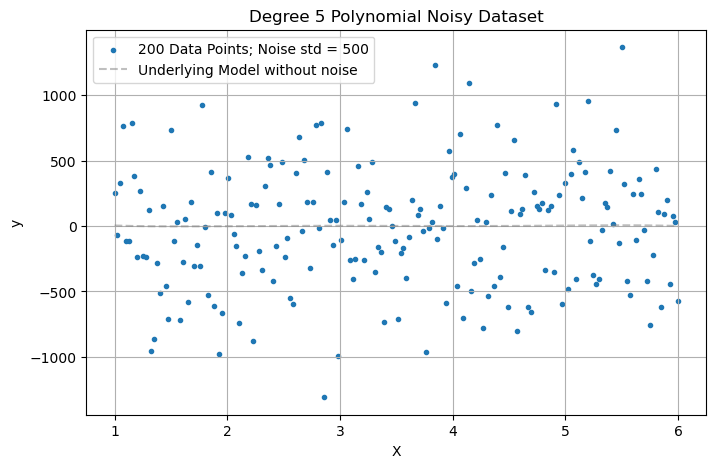

,Degree,Train MSE,Evaluation MSE
0,1,209983.801947,226309.509458
1,2,208296.124294,232684.233246
2,3,207092.821952,229903.539114
3,4,206790.386087,230784.715560
4,5,199470.678011,226229.573542
5,6,199367.256086,225610.270201
6,7,198656.909439,226011.654200
7,8,198544.343126,225884.443295
8,9,197205.482756,225909.672582
9,10,197118.153578,226173.833190


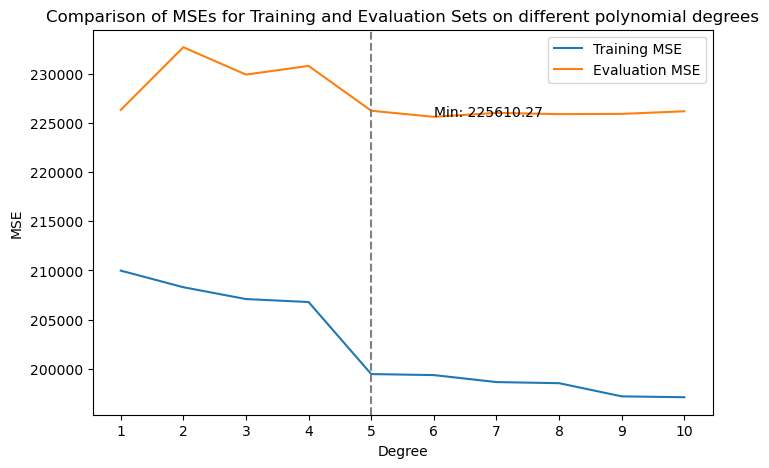

,Degree,Train MSE,Evaluation MSE
5,6,199367.256086,225610.270201


In [12]:
x1, y1 = make_poly_model(
    n_samples= 200,
    degree = 5, 
    noise =500, 
    random_state= random_seed,
    show_data=True
)

x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1,
    y1,
    test_size = 0.3
    
)


degrees = range(1,11) 
train_errors = []     # store training MSEs for each degree here
evaluation_errors  = []     # store evaluation MSEs for each degree here

for d in degrees:

    poly_df = PolynomialFeatures(degree=d, include_bias=False)
    x1poly_train = poly_df.fit_transform(x1_train)
    x1poly_test = poly_df.transform(x1_test)

    mod1 = LinearRegression()
    mod1.fit(x1poly_train, y1_train)

    # Predict on the train and evaluation sets

    y1_train_pred = mod1.predict(x1poly_train)
    y1_test_pred = mod1.predict(x1poly_test)

    # Calculate the MSEs and append to the appropriate lists

    train_errors.append(mean_squared_error(y1_train, y1_train_pred))
    evaluation_errors.append(mean_squared_error(y1_test, y1_test_pred))
    

    
# Plot training and evaluation MSEs vs degree of model using train_errors and evaluation_errors

comparetable1 = pd.DataFrame(
    zip(
        degrees,
        train_errors,
        evaluation_errors
    )
    , columns=['Degree', 'Train MSE', 'Evaluation MSE']
)
display(comparetable1)


plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, label='Training MSE')
plt.plot(degrees, evaluation_errors, label='Evaluation MSE')
plt.xlabel('Degree')
plt.xticks(range(1,11))
plt.ylabel('MSE')
plt.legend()
plt.annotate(f'Min: {min(evaluation_errors):.2f}', xy= (6, min(evaluation_errors)))
plt.axvline(x=5, color='grey', linestyle='--')
plt.title("Comparison of MSEs for Training and Evaluation Sets on different polynomial degrees")
plt.show()


comparetable1.query("`Evaluation MSE` == `Evaluation MSE`.min()")
